## **Curso**: Residência em Inteligência Artificial
## **Unidade Curricular**: Aprendizado por Reforço
## **Desafio**: Planejamento com Modelo no Taxi-v3
---

Neste desafio expandimos o que foi feito no **FrozenLake** para um ambiente mais
rico e com muito mais estados: o **Taxi-v3**. A ideia é usar o mesmo princípio de
**planejamento com modelo** (acesso à tabela de transições `env.P`) e aplicar
**Value Iteration** e **Policy Iteration**.

O `Taxi-v3` é um ambiente discreto em que um táxi precisa:

* navegar em uma grade,
* buscar um passageiro em um ponto,
* levar o passageiro até o destino correto,
* e realizar o *drop-off* no local certo.

O espaço de estados é bem maior do que no FrozenLake (**500 estados**), porque o
estado codifica a posição do táxi, onde está o passageiro e qual é o destino.

> Doc completa: https://gymnasium.farama.org/environments/toy_text/taxi/

### Objetivos
1. usar `env.P` para planejar em um ambiente do Gymnasium (modelo conhecido);
2. implementar **Value Iteration** e **Policy Iteration** do zero;
3. gerar uma policy determinística a partir dos valores;
4. testar a policy em episódios no ambiente;
5. comparar eficiência (tempo e iterações) e o impacto do fator de desconto `gamma`;
6. visualizar o agente executando a policy final.


## 🔧 Setup


In [21]:
! pip install -qq gymnasium[toy_text] pygame moviepy imageio seaborn matplotlib numpy pillow


In [22]:
import time
import math
import random

import gymnasium as gym
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation

%matplotlib inline

np.random.seed(0)
random.seed(0)


Assim como fizemos com o FrozenLake, vamos abstrair a criação do ambiente em
`make_env()`. Usamos `render_mode='rgb_array'` para conseguir gerar os frames do
vídeo no final, e `.unwrapped` para ter acesso direto à matriz de transições `env.P`.


> **Nota de versão:** o desafio pede `Taxi-v3`. Em versões recentes do Gymnasium
> esse id foi descontinuado em favor de `Taxi-v4` (mesmo ambiente, 500 estados).
> A função abaixo tenta `Taxi-v3` e, se não existir, cai para `Taxi-v4` — assim o
> notebook roda tanto no Colab quanto em ambientes atualizados.


In [23]:
def make_env(render_mode='rgb_array'):
    for env_id in ('Taxi-v3', 'Taxi-v4'):
        try:
            env = gym.make(env_id, render_mode=render_mode)
            return env.unwrapped
        except gym.error.Error:
            continue
    raise RuntimeError('Nenhuma versão do ambiente Taxi encontrada.')


env = make_env()
env


## 1) Explorar o modelo do ambiente

Vamos obter o número de estados `nS` e de ações `nA`, e inspecionar alguns
exemplos de `env.P[s][a]` para entender o modelo.


In [24]:
obs, info = env.reset(seed=0)

nS = env.observation_space.n
nA = env.action_space.n

print(f"Observação inicial (estado): {obs}")
print(f"Número de estados  nS = {nS}")
print(f"Número de ações    nA = {nA}")
print(f"observation_space: {env.observation_space}")
print(f"action_space:      {env.action_space}")


Observação inicial (estado): 314
Número de estados  nS = 500
Número de ações    nA = 6
observation_space: Discrete(500)
action_space:      Discrete(6)


### As 6 ações do Taxi-v3

| Índice | Ação           |
|:------:|----------------|
| 0      | mover **Sul**  (↓) |
| 1      | mover **Norte** (↑) |
| 2      | mover **Leste** (→) |
| 3      | mover **Oeste** (←) |
| 4      | **Pegar** passageiro (pickup) |
| 5      | **Deixar** passageiro (drop-off) |

### Recompensas
* `-1` por passo (incentiva o menor caminho);
* `-10` por *pickup* ou *drop-off* ilegal;
* `+20` por entregar o passageiro no destino correto (estado terminal).

### Codificação do estado
Cada estado é um inteiro em `[0, 500)`. Podemos decodificá-lo com
`env.unwrapped.decode(s)`, que devolve `(linha_táxi, coluna_táxi, local_passageiro, destino)`.


### Interpretando `env.P[s][a]`

`env.P[s][a]` é uma lista de transições no formato
`(prob, next_state, reward, terminated)`. No Taxi-v3 o ambiente é
**determinístico**, então cada `(s, a)` tem uma única transição com `prob = 1.0`.


In [25]:
P = env.P  # P[s][a] -> lista de (prob, next_state, reward, terminated)


def descreve_estado(s):
    taxi_row, taxi_col, pass_loc, dest = env.unwrapped.decode(s)
    locais = ['R', 'G', 'Y', 'B', 'no_taxi']
    return (f"taxi=({taxi_row},{taxi_col}), "
            f"passageiro={locais[pass_loc]}, destino={locais[dest]}")


exemplos = [(obs, 0), (obs, 4), (obs, 5)]
acoes = {0: 'Sul', 1: 'Norte', 2: 'Leste', 3: 'Oeste', 4: 'Pickup', 5: 'Drop-off'}

for s, a in exemplos:
    print(f"Estado s={s} -> {descreve_estado(s)}")
    print(f"  Ação a={a} ({acoes[a]}):")
    for prob, next_state, reward, terminated in P[s][a]:
        print(f"     p={prob:.2f} -> s'={next_state}, r={reward}, terminal={terminated}")
    print()


Estado s=314 -> taxi=(3,0), passageiro=B, destino=Y
  Ação a=0 (Sul):
     p=1.00 -> s'=414, r=-1, terminal=False

Estado s=314 -> taxi=(3,0), passageiro=B, destino=Y
  Ação a=4 (Pickup):
     p=1.00 -> s'=314, r=-10, terminal=False

Estado s=314 -> taxi=(3,0), passageiro=B, destino=Y
  Ação a=5 (Drop-off):
     p=1.00 -> s'=314, r=-10, terminal=False



**Como ler:** estando no estado `s` e tomando a ação `a`, o ambiente vai para
`next_state` com probabilidade `prob`, entrega a recompensa `reward` e informa em
`terminated` se o episódio acabou. Note que:

* mover-se custa `-1` (ação 0);
* um *pickup* onde não há passageiro custa `-10` (ação 4);
* um *drop-off* ilegal custa `-10` (ação 5).

Como `prob = 1.0` em todas as transições, o Taxi-v3 é determinístico — o que não
diminui a dificuldade do planejamento, já que o horizonte é longo.


## 2) Value Iteration

Aplicamos a **atualização de Bellman de otimalidade** repetidamente até a maior
mudança de valor (`delta`) ficar abaixo de `theta`.

> Pseudocódigo
```text
inicialize V(s) = 0 para todo estado s
repita:
    delta = 0
    para cada estado s:
        v_antigo = V(s)
        para cada ação a:
            q(a) = soma de [prob * (reward + γ * V(next_state))]
        V(s) = max_a q(a)
        delta = max(delta, |v_antigo - V(s)|)
até delta < theta
retorne V
```


In [26]:
def compute_state_values(env, gamma=0.99, theta=1e-6, max_iter=10000):
    """Value Iteration: calcula V(s) ótimo. Retorna (V, n_iteracoes)."""
    nS = env.observation_space.n
    nA = env.action_space.n
    V = np.zeros(nS)

    i = 0
    while i < max_iter:
        i += 1
        delta = 0
        for s in range(nS):
            v = V[s]
            q_values = np.zeros(nA)
            for a in range(nA):
                for prob, next_state, reward, terminated in env.P[s][a]:
                    # Bellman: Q(s,a) = sum p * (r + gamma * V(s') * (1 - terminal))
                    q_values[a] += prob * (
                        reward + gamma * V[next_state] * (not terminated)
                    )
            V[s] = np.max(q_values)
            delta = max(delta, abs(v - V[s]))

        if delta < theta:
            break

    return V, i


### Policy greedy a partir de V(s)

Para cada estado escolhemos a ação de maior valor esperado (Bellman de 1 passo)
e marcamos com `1.0` — gerando uma policy **determinística one-hot**.

> Pseudocódigo
```text
para cada estado s:
    para cada ação a:
        q(a) = soma de [prob * (reward + γ * V(next_state))]
    best = argmax q(a)
    policy[s, best] = 1
```


In [27]:
def build_greedy_policy_from_values(env, V, gamma=0.99):
    nS = env.observation_space.n
    nA = env.action_space.n

    Q = np.zeros([nS, nA])
    policy = np.zeros([nS, nA])

    for s in range(nS):
        for a in range(nA):
            for prob, next_state, reward, terminated in env.P[s][a]:
                Q[s, a] += prob * (
                    reward + gamma * V[next_state] * (not terminated)
                )
        best_action = np.argmax(Q[s])
        policy[s, best_action] = 1.0

    return policy, Q


In [28]:
def value_iteration(env, gamma=0.99, theta=1e-6):
    V, n_iter = compute_state_values(env, gamma=gamma, theta=theta)
    policy, Q = build_greedy_policy_from_values(env, V, gamma=gamma)
    return V, policy, Q, n_iter


V_vi, pol_vi, Q_vi, iters_vi = value_iteration(env, gamma=0.99)
print(f"Value Iteration convergiu em {iters_vi} iterações.")
print(f"V(estado inicial {obs}) = {V_vi[obs]:.3f}")
print(f"Ação greedy no estado inicial: {np.argmax(pol_vi[obs])} "
      f"({acoes[int(np.argmax(pol_vi[obs]))]})")


Value Iteration convergiu em 13 iterações.
V(estado inicial 314) = 4.249
Ação greedy no estado inicial: 1 (Norte)


## 3) Policy Iteration (DESAFIO)

O Policy Iteration alterna dois passos até a policy estabilizar:

1. **Policy Evaluation** — calcula `V(s)` de uma policy fixa;
2. **Policy Improvement** — gera uma policy greedy a partir de `V(s)`.


### 3.1 Policy Evaluation

> Pseudocódigo
```text
repita:
    delta = 0
    para cada estado s:
        v = 0
        para cada ação a:
            v += π(a|s) * soma de [prob * (reward + γ * V(next_state))]
        delta = max(delta, |v - V(s)|)
        V(s) = v
até delta < theta
```


In [29]:
def policy_evaluation(env, policy, gamma=0.99, theta=1e-6, max_iter=10000):
    """Calcula V(s) para uma policy fixa. Retorna (V, n_iteracoes)."""
    nS = env.observation_space.n
    nA = env.action_space.n
    V = np.zeros(nS)

    i = 0
    while i < max_iter:
        i += 1
        delta = 0
        for s in range(nS):
            v_novo = 0.0
            for a in range(nA):
                pi_a = policy[s, a]
                if pi_a == 0:
                    continue
                for prob, next_state, reward, terminated in env.P[s][a]:
                    v_novo += pi_a * prob * (
                        reward + gamma * V[next_state] * (not terminated)
                    )
            delta = max(delta, abs(v_novo - V[s]))
            V[s] = v_novo
        if delta < theta:
            break

    return V, i


### 3.2 Policy Improvement

> Pseudocódigo
```text
para cada estado s:
    para cada ação a:
        q(a) = soma de [prob * (reward + γ * V(next_state))]
    best = argmax q(a)
    new_policy[s, best] = 1
```


In [30]:
def policy_improvement(env, V, gamma=0.99, old_policy=None):
    nS = env.observation_space.n
    nA = env.action_space.n
    new_policy = np.zeros([nS, nA])

    for s in range(nS):
        q_values = np.zeros(nA)
        for a in range(nA):
            for prob, next_state, reward, terminated in env.P[s][a]:
                q_values[a] += prob * (
                    reward + gamma * V[next_state] * (not terminated)
                )
        best_action = int(np.argmax(q_values))
        # Em empates, mantém a ação anterior (evita oscilação no PI)
        if old_policy is not None:
            old_a = int(np.argmax(old_policy[s]))
            if q_values[old_a] >= q_values[best_action] - 1e-12:
                best_action = old_a
        new_policy[s, best_action] = 1.0

    return new_policy


### 3.3 O laço de Policy Iteration

Começamos com uma policy uniforme e repetimos avaliação/melhoria até a policy
parar de mudar. Contamos tanto as **iterações externas** quanto o **total de
iterações de avaliação** (varreduras internas), para comparar com o VI depois.


In [31]:
def policy_iteration(env, gamma=0.99, theta=1e-6, max_outer=100):
    nS = env.observation_space.n
    nA = env.action_space.n

    # policy inicial uniforme (aleatória)
    policy = np.ones([nS, nA]) / nA

    outer = 0
    total_eval_sweeps = 0
    while outer < max_outer:
        outer += 1
        V, eval_sweeps = policy_evaluation(env, policy, gamma=gamma, theta=theta)
        total_eval_sweeps += eval_sweeps

        new_policy = policy_improvement(env, V, gamma=gamma, old_policy=policy)

        # convergiu quando a ação greedy não muda em nenhum estado
        if np.array_equal(np.argmax(new_policy, axis=1),
                          np.argmax(policy, axis=1)):
            policy = new_policy
            break
        policy = new_policy

    # Policy final greedy pura (mesmo criterio do VI em empates)
    policy = policy_improvement(env, V, gamma=gamma)
    return V, policy, outer, total_eval_sweeps


V_pi, pol_pi, outer_pi, eval_pi = policy_iteration(env, gamma=0.99)
print(f"Policy Iteration convergiu em {outer_pi} iterações externas "
      f"({eval_pi} varreduras de avaliação no total).")
print(f"V(estado inicial {obs}) = {V_pi[obs]:.3f}")


Policy Iteration convergiu em 2 iterações externas (1172 varreduras de avaliação no total).
V(estado inicial 314) = 4.249


### Sanidade: VI e PI encontram a mesma policy?

Como ambos resolvem a mesma Equação de Bellman de Otimalidade, a policy greedy
resultante deve ser idêntica (garantia teórica).


In [32]:
mesma_policy = np.array_equal(np.argmax(pol_vi, axis=1),
                              np.argmax(pol_pi, axis=1))
print(f"VI e PI produziram a MESMA policy? {mesma_policy}")
print(f"Diferença máxima entre V_vi e V_pi: {np.max(np.abs(V_vi - V_pi)):.6f}")


VI e PI produziram a MESMA policy? True
Diferença máxima entre V_vi e V_pi: 0.000000


## 🎮 Função de simulação da policy

Roda `N` episódios seguindo a policy determinística e reporta **retorno médio**,
**passos médios** e **taxa de sucesso** (episódio que termina com a entrega, i.e.
recompensa `+20` no último passo). Usamos `max_steps` como salvaguarda contra
loops em policies ruins (ex.: `gamma` muito baixo).


In [33]:
def run_policy(env, policy, n_episodes=100, gamma=0.99,
               max_steps=200, seed=0):
    retornos, passos, sucessos = [], [], 0

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        G, t, done = 0.0, 0, False
        last_reward = 0
        while not done and t < max_steps:
            action = int(np.argmax(policy[state]))
            state, reward, terminated, truncated, _ = env.step(action)
            G += (gamma ** t) * reward
            last_reward = reward
            done = terminated or truncated
            t += 1
        retornos.append(G)
        passos.append(t)
        if last_reward == 20:  # entrega bem-sucedida
            sucessos += 1

    return {
        'retorno_medio': float(np.mean(retornos)),
        'passos_medios': float(np.mean(passos)),
        'taxa_sucesso': sucessos / n_episodes,
    }


## 4) Comparação de eficiência: VI vs PI

Para `gamma = 0.99` e o mesmo `theta`, comparamos número de iterações, tempo de
execução e desempenho em simulação (`N = 100` episódios).


In [34]:
GAMMA = 0.99
THETA = 1e-6
N_EPISODES = 100

# --- Value Iteration
t0 = time.perf_counter()
V_vi, pol_vi, Q_vi, iters_vi = value_iteration(env, gamma=GAMMA, theta=THETA)
tempo_vi = time.perf_counter() - t0
sim_vi = run_policy(env, pol_vi, n_episodes=N_EPISODES, gamma=GAMMA)

# --- Policy Iteration
t0 = time.perf_counter()
V_pi, pol_pi, outer_pi, eval_pi = policy_iteration(env, gamma=GAMMA, theta=THETA)
tempo_pi = time.perf_counter() - t0
sim_pi = run_policy(env, pol_pi, n_episodes=N_EPISODES, gamma=GAMMA)


In [ ]:
print(f"{'Métrica':<55}{'Value Iteration':>18}{'Policy Iteration':>18}")
print("-" * 91)
print(f"{'Varreduras do Value Iteration (até V convergir)':<55}{iters_vi:>18}{'-':>18}")
print(f"{'Iterações externas do Policy Iteration':<55}{'-':>18}{outer_pi:>18}")
print(f"{'Varreduras internas de avaliação (Policy Iteration)':<55}{'-':>18}{eval_pi:>18}")
print(f"{'Tempo (s)':<55}{tempo_vi:>18.3f}{tempo_pi:>18.3f}")
print(f"{'Retorno médio':<55}{sim_vi['retorno_medio']:>18.3f}"
      f"{sim_pi['retorno_medio']:>18.3f}")
print(f"{'Passos médios':<55}{sim_vi['passos_medios']:>18.2f}"
      f"{sim_pi['passos_medios']:>18.2f}")
print(f"{'Taxa de sucesso':<55}{sim_vi['taxa_sucesso']:>18.2%}"
      f"{sim_pi['taxa_sucesso']:>18.2%}")


**Como ler a tabela (sem ambiguidade):**

Ambos chegam à **mesma policy ótima** (mesmo retorno, mesmos passos, 100% de sucesso).
A diferença é *como* cada algoritmo trabalha — e as linhas de contagem medem **coisas distintas**:

* **Varreduras do Value Iteration:** quantas vezes o Value Iteration percorreu todos os estados até `V` estabilizar (`delta < theta`). Cada varredura é relativamente barata.
* **Iterações externas do Policy Iteration:** quantos ciclos *avaliar policy → melhorar policy* até a policy parar de mudar. Em geral são **pouquíssimas**: a policy estabiliza rápido.
* **Varreduras internas de avaliação (Policy Iteration):** soma de todas as varreduras feitas *dentro* das Policy Evaluations. Esse número pode ser **grande** mesmo com só 2 iterações externas — por isso o Policy Iteration costuma gastar **mais tempo**, embora tenha menos passos de alto nível.

**Comparação justa de “nível alto”:** varreduras do Value Iteration **versus** iterações externas do Policy Iteration (ex.: 13 vs 2).  
O total de avaliação do Policy Iteration (ex.: ~1172) **não** é a mesma unidade que as 13 varreduras do Value Iteration; ele explica o custo interno (e o tempo) do Policy Iteration.


## 5) Impacto do fator de desconto `gamma`

Fixamos `theta` e variamos apenas `gamma`. Para cada valor rodamos VI e PI,
extraímos a policy e medimos o **retorno médio** em `N` episódios.


In [ ]:
GAMMAS = [0.1, 0.5, 0.9, 0.99]
N_EPISODES = 100

resultados = {'gamma': [], 'vi_retorno': [], 'pi_retorno': [],
              'vi_sucesso': [], 'pi_sucesso': [],
              'vi_iters': [], 'pi_outer': [],
              'vi_tempo': [], 'pi_tempo': []}

# Artefatos para visualizacao (VI == PI na policy otima)
policies_por_gamma = {}
Q_por_gamma = {}
V_por_gamma = {}
tempos_por_gamma = {}  # tempo ate achar a policy otima (VI e PI)

for g in GAMMAS:
    print(f"\n>>> gamma={g}: iniciando Value Iteration...", flush=True)
    t0 = time.perf_counter()
    V_g, pol_g, Q_g, it_g = value_iteration(env, gamma=g, theta=THETA)
    tempo_vi_g = time.perf_counter() - t0
    print(f">>> gamma={g}: VI ok ({it_g} iters, {tempo_vi_g:.3f}s). Simulando...", flush=True)
    sim_g_vi = run_policy(env, pol_g, n_episodes=N_EPISODES, gamma=g)

    print(f">>> gamma={g}: iniciando Policy Iteration...", flush=True)
    t0 = time.perf_counter()
    V_gp, pol_gp, outer_gp, eval_gp = policy_iteration(env, gamma=g, theta=THETA)
    tempo_pi_g = time.perf_counter() - t0
    print(f">>> gamma={g}: PI ok (outer={outer_gp}, eval={eval_gp}, {tempo_pi_g:.3f}s). Simulando...", flush=True)
    sim_g_pi = run_policy(env, pol_gp, n_episodes=N_EPISODES, gamma=g)

    # Guarda Q/V/policy da VI (mesma policy otima que o PI)
    policies_por_gamma[g] = pol_g
    Q_por_gamma[g] = Q_g
    V_por_gamma[g] = V_g
    tempos_por_gamma[g] = {
        'vi': tempo_vi_g,
        'pi': tempo_pi_g,
        'vi_iters': it_g,
        'pi_outer': outer_gp,
        'pi_eval': eval_gp,
    }

    resultados['gamma'].append(g)
    resultados['vi_retorno'].append(sim_g_vi['retorno_medio'])
    resultados['pi_retorno'].append(sim_g_pi['retorno_medio'])
    resultados['vi_sucesso'].append(sim_g_vi['taxa_sucesso'])
    resultados['pi_sucesso'].append(sim_g_pi['taxa_sucesso'])
    resultados['vi_iters'].append(it_g)
    resultados['pi_outer'].append(outer_gp)
    resultados['vi_tempo'].append(tempo_vi_g)
    resultados['pi_tempo'].append(tempo_pi_g)

    print(f"gamma={g:<5} | VI ret={sim_g_vi['retorno_medio']:8.3f} "
          f"suc={sim_g_vi['taxa_sucesso']:5.0%} it={it_g:<4} t={tempo_vi_g:6.3f}s | "
          f"PI ret={sim_g_pi['retorno_medio']:8.3f} "
          f"suc={sim_g_pi['taxa_sucesso']:5.0%} out={outer_gp} t={tempo_pi_g:6.3f}s",
          flush=True)


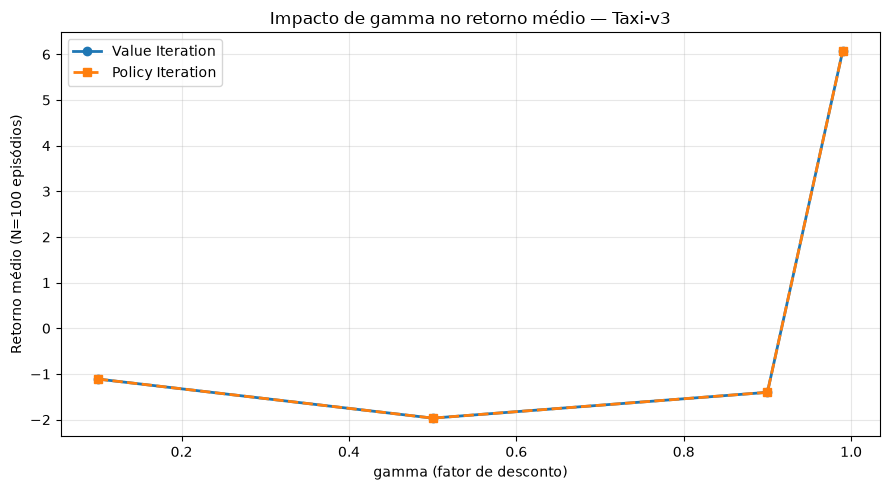

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(resultados['gamma'], resultados['vi_retorno'],
        marker='o', linewidth=2, label='Value Iteration')
ax.plot(resultados['gamma'], resultados['pi_retorno'],
        marker='s', linewidth=2, linestyle='--', label='Policy Iteration')

ax.set_xlabel('gamma (fator de desconto)')
ax.set_ylabel('Retorno médio (N=100 episódios)')
ax.set_title('Impacto de gamma no retorno médio — Taxi-v3')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


Como VI e PI convergem para a mesma policy em cada `gamma`, as duas curvas
praticamente se sobrepõem. O ponto central do gráfico é o **salto de desempenho
conforme `gamma` cresce**: com `gamma` baixo o agente é *míope* e não consegue
planejar a sequência longa (ir até o passageiro → pickup → ir ao destino →
drop-off), colapsando o retorno; com `gamma` alto (0.9–0.99) ele enxerga a
recompensa distante de `+20` e resolve a tarefa.


## 5.1) Comparação visual das policies por `gamma`

> **Ordem de execução:** rode antes o sweep de `GAMMAS` (célula que cria
> `Q_por_gamma` / `policies_por_gamma` / `tempos_por_gamma`). Depois rode as duas células abaixo.

O Taxi tem **500 estados**, então usamos uma **fatia 5×5** (passageiro/destino
fixos do `seed=42`) — mesmo espírito do FrozenLake/Monte Carlo.

Para cada `gamma` exibimos o **tempo de planejamento** até a policy ótima e, nesta ordem:
1. **Q-Values** \(Q(s,a)\) em triângulos + frame (`Estado Atual`);
2. **Politica aprendida** (letras S/N/L/O/P/D) + frame;
3. **GIF** do episódio com aquela policy;
4. **vídeo (MP4)** do mesmo episódio (salvo em disco e exibido em seguida).


In [ ]:
from IPython.display import Image, display, Video, Markdown
from moviepy import ImageSequenceClip


def slice_taxi_indices(env, pass_loc, dest):
    """Estados da fatia 5x5 (todas posicoes do taxi) para pass_loc/dest fixos."""
    idxs = []
    for row in range(5):
        for col in range(5):
            idxs.append(env.encode(row, col, pass_loc, dest))
    return np.array(idxs)


def slice_taxi_Q(Q, env, pass_loc, dest):
    """Retorna Q_slice shape (25, nA) na ordem row-major da grade 5x5."""
    idxs = slice_taxi_indices(env, pass_loc, dest)
    return Q[idxs]


def plot_action_values_taxi(Q, frame, env, pass_loc, dest,
                            title='Estimated State Values (Max Q)'):
    """Heatmap V=max_a Q na fatia 5x5 + frame (estilo Monte Carlo)."""
    Q_slice = slice_taxi_Q(Q, env, pass_loc, dest)
    V = np.max(Q_slice, axis=1).reshape(5, 5)
    f, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(V, annot=True, fmt='.2f', cmap='coolwarm',
                annot_kws={'weight': 'bold'}, linewidths=2, ax=axes[0])
    axes[1].imshow(frame)
    axes[0].set_title(title)
    axes[0].axis('off')
    axes[1].set_title('Estado Atual')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()


def plot_policy_taxi(Q, frame, env, pass_loc, dest, title='Politica aprendida'):
    """Heatmap da acao gulosa na fatia 5x5 (estilo Monte Carlo / imagem)."""
    action_meanings = {0: 'S', 1: 'N', 2: 'L', 3: 'O', 4: 'P', 5: 'D'}
    Q_slice = slice_taxi_Q(Q, env, pass_loc, dest)
    max_actions = np.argmax(Q_slice, axis=1).reshape(5, 5)
    annot_grid = max_actions.copy().astype(object)
    for key, letter in action_meanings.items():
        annot_grid[annot_grid == key] = letter

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    sns.heatmap(max_actions, annot=annot_grid, fmt='', cbar=False, cmap='coolwarm',
                annot_kws={'weight': 'bold'}, linewidths=2, ax=axes[0])
    axes[1].imshow(frame)
    axes[0].set_title(title)
    axes[0].axis('off')
    axes[1].set_title('Estado Atual')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()


def plot_q_values_taxi(Q, frame, env, pass_loc, dest, title='Q-Values $Q(s, a)$'):
    """
    Q-values na fatia 5x5: triangulos para movimentos (0-3) + frame.
    Layout igual ao FrozenLake/Monte Carlo da imagem de referencia.
    Se a acao gulosa for Pickup(4) ou Drop-off(5), anota P/D e o Q-value no centro.
    """
    Q_slice = slice_taxi_Q(Q, env, pass_loc, dest)  # (25, 6)
    grid_size = 5
    n_states = 25

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ax = axes[0]
    ax.set_xlim(0, grid_size)
    ax.set_ylim(0, grid_size)
    ax.set_title(title)
    ax.invert_yaxis()

    move_q = Q_slice[:, :4]
    min_q = float(np.min(move_q))
    max_q = float(np.max(move_q))

    for s in range(n_states):
        row, col = divmod(s, grid_size)
        x, y = col, row
        center = [x + 0.5, y + 0.5]
        # Taxi: 0 Sul, 1 Norte, 2 Leste, 3 Oeste
        triangles = {
            0: [[x, y + 1], [x + 1, y + 1], center],  # South
            1: [[x, y], [x + 1, y], center],            # North
            2: [[x + 1, y], [x + 1, y + 1], center],  # East
            3: [[x, y], [x, y + 1], center],            # West
        }
        for a in range(4):
            val = Q_slice[s, a]
            color = plt.cm.coolwarm((val - min_q) / (max_q - min_q + 1e-6))
            poly = plt.Polygon(triangles[a], facecolor=color, edgecolor='white', lw=1)
            ax.add_patch(poly)
            tx, ty = center[0], center[1]
            offset = 0.32
            if a == 0:
                ty += offset
            elif a == 1:
                ty -= offset
            elif a == 2:
                tx += offset
            elif a == 3:
                tx -= offset
            ax.text(tx, ty, f'{val:.2f}', ha='center', va='center',
                    fontsize=7, fontweight='bold', color='black')

        best = int(np.argmax(Q_slice[s]))
        # Verde limão destaca Pickup/Drop-off (letra + Q) no centro da célula
        pd_color = 'lime'
        if best == 4:
            ax.text(center[0], center[1] - 0.12, 'P', ha='center', va='center',
                    fontsize=10, fontweight='bold', color=pd_color)
            ax.text(center[0], center[1] + 0.18, f'{Q_slice[s, 4]:.2f}',
                    ha='center', va='center', fontsize=6, fontweight='bold',
                    color=pd_color)
        elif best == 5:
            ax.text(center[0], center[1] - 0.12, 'D', ha='center', va='center',
                    fontsize=10, fontweight='bold', color=pd_color)
            ax.text(center[0], center[1] + 0.18, f'{Q_slice[s, 5]:.2f}',
                    ha='center', va='center', fontsize=6, fontweight='bold',
                    color=pd_color)

    axes[1].imshow(frame)
    axes[1].set_title('Estado Atual')
    ax.set_aspect('equal')
    ax.axis('off')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()


def test_agent_policy(env, policy, seed=42, max_steps=200):
    """Coleta frames de um episodio seguindo a policy (estilo test_agent do MC)."""
    frames = []
    state, info = env.reset(seed=seed)
    frames.append(env.render())
    done, t = False, 0
    while not done and t < max_steps:
        action = int(np.argmax(policy[state]))
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        frames.append(env.render())
        t += 1
    return frames


def display_video(frames, fps=5, filename='taxi_rollout.mp4'):
    clip = ImageSequenceClip(frames, fps=fps)
    clip.write_videofile(filename, codec='libx264', audio=False)
    return Video(filename, width=500, height=500, embed=True)


def display_gif(frames, fps=3, filename='temp_animation.gif'):
    """Exibe GIF na tela (estilo notebook Monte Carlo)."""
    orig_backend = matplotlib.get_backend()
    matplotlib.use('Agg')
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    try:
        ax.set_axis_off()
        ax.set_aspect('equal')
        ax.set_position([0, 0, 1, 1])
        im = ax.imshow(frames[0])

        def update(frame):
            im.set_data(frame)
            return [im]

        anim = animation.FuncAnimation(fig, update, frames=frames, blit=True)
        anim.save(filename, writer='pillow', fps=fps)
    finally:
        plt.close(fig)
        matplotlib.use(orig_backend)
    display(Image(filename=filename))
    print(f'(GIF salvo em {filename})')


In [ ]:
# Estado de referencia (mesmo seed do video) para fatia e episodios comparaveis
from IPython.display import Markdown, display

assert 'Q_por_gamma' in dir() and len(Q_por_gamma) > 0, (
    "Rode antes a celula do sweep de GAMMAS (cria Q_por_gamma / policies_por_gamma)."
)
assert 'tempos_por_gamma' in dir() and len(tempos_por_gamma) > 0, (
    "Rode de novo o sweep de GAMMAS (agora tambem cria tempos_por_gamma)."
)

GAMMA_NOTAS = {
    0.1: (
        "Gamma **muito baixo** (agente *miope*): o futuro quase nao conta. "
        "A recompensa +20 da entrega e descontada quase a zero. "
        "Espere Q-values pouco 'orientados' para a tarefa longa e um episodio "
        "que frequentemente **nao completa** a corrida."
    ),
    0.5: (
        "Gamma **moderado**: o agente enxerga um pouco mais a frente, mas ainda "
        "desconta forte o horizonte longo. Compare a policy e o rollout com 0.1 "
        "e com 0.9/0.99."
    ),
    0.9: (
        "Gamma **alto**: o horizonte de planejamento cobre bem pickup → transporte → drop-off. "
        "Em geral a policy ja resolve a tarefa com boa taxa de sucesso."
    ),
    0.99: (
        "Gamma **proximo de 1** (agente *previdente*): valoriza fortemente o futuro. "
        "Esta e a policy tipicamente otima para o Taxi neste desafio — "
        "espere completar a entrega no GIF/video."
    ),
}

DEMO_SEED = 42
env_vis = make_env(render_mode='rgb_array')
state0, _ = env_vis.reset(seed=DEMO_SEED)
taxi_row, taxi_col, pass_loc, dest = list(env_vis.decode(state0))
frame0 = env_vis.render()

locais = ['R', 'G', 'Y', 'B', 'no_taxi']
display(Markdown(
    f"""## Comparacao visual por gamma

Fatia **5x5** com passageiro=`{locais[pass_loc]}`, destino=`{locais[dest]}`
(estado inicial `seed={DEMO_SEED}`, taxi=`({taxi_row},{taxi_col})`).

Para **cada** valor de gamma abaixo voce vera, nesta ordem:
1. **Q-Values** (triangulos) + frame
2. **Politica aprendida** (letras) + frame
3. **GIF** do episodio com aquela policy
4. **video (MP4)** do mesmo episodio (salvo e exibido em seguida)
"""
))

for g in GAMMAS:
    assert g in Q_por_gamma, f"gamma={g} ausente em Q_por_gamma — rode o sweep."
    nota = GAMMA_NOTAS.get(g, "Observe como Q, policy e o episodio mudam com este desconto.")
    Qg = Q_por_gamma[g]
    pol_g = policies_por_gamma[g]

    tinfo = tempos_por_gamma[g]
    display(Markdown(
        f"""---
## Resultados para `gamma = {g}`

{nota}

**Tempo ate achar a policy otima** (medido no sweep, so o planejamento — sem simulacao):
- **Value Iteration:** `{tinfo['vi']:.3f} s` ({tinfo['vi_iters']} varreduras)
- **Policy Iteration:** `{tinfo['pi']:.3f} s` ({tinfo['pi_outer']} iteracoes externas, {tinfo['pi_eval']} varreduras de avaliacao)

A grade abaixo e a **mesma fatia espacial** (mesmo passageiro/destino) para todos os gammas,
para a comparacao ser justa.
"""
    ))

    display(Markdown(
        f"""### 1) Q-Values $Q(s,a)$ — gamma={g}

Cada celula da grade 5x5 e a posicao do taxi. Os **triangulos** sao as acoes de movimento
(S/N/L/O). Cores quentes = maior Q. Se a acao gulosa for **Pickup** ou **Drop-off**,
aparece **P** ou **D** no centro em **verde limao**, com o Q-value dessa acao (mesma cor) logo abaixo.
A direita: frame do estado de referencia.
"""
    ))
    plot_q_values_taxi(
        Qg, frame0, env_vis, pass_loc, dest,
        title=f'Q-Values $Q(s, a)$ | gamma={g}'
    )

    display(Markdown(
        f"""### 2) Politica aprendida — gamma={g}

Cada letra e a acao **gulosa** (`argmax Q`) naquela posicao do taxi:
**S**=Sul, **N**=Norte, **L**=Leste, **O**=Oeste, **P**=Pickup, **D**=Drop-off.
Compare com o mapa de Q acima: a policy resume so a melhor acao.
"""
    ))
    plot_policy_taxi(
        Qg, frame0, env_vis, pass_loc, dest,
        title=f'Politica aprendida | gamma={g}'
    )

    display(Markdown(
        f"""### 3) Execucao do episodio — gamma={g}

Abaixo: **GIF** e depois o **video (MP4)** do mesmo episodio (`seed={DEMO_SEED}`).
Observe se ele **completa** pickup → destino → drop-off, ou se falha / atinge o limite de passos.
"""
    ))
    frames_g = test_agent_policy(env_vis, pol_g, seed=DEMO_SEED, max_steps=200)
    n_passos = len(frames_g) - 1
    gif_name = f'taxi_gamma_{g}.gif'
    mp4_name = f'taxi_gamma_{g}.mp4'
    display(Markdown(
        f"**Episodio com gamma={g}:** {n_passos} passos. "
        f"GIF: `{gif_name}` → em seguida video: `{mp4_name}`."
    ))
    display_gif(frames_g, fps=3, filename=gif_name)
    display(Markdown(f"**Video (MP4):** `{mp4_name}`"))
    display(display_video(frames_g, fps=5, filename=mp4_name))

    display(Markdown(
        f"""#### Fim do bloco `gamma = {g}`

---
"""
    ))

env_vis.close()
display(Markdown("## Comparacao visual por gamma concluida."))


## 5.2) Galeria de episódios (visualização no GitHub)

Os GIFs e MP4s abaixo são os artefatos gerados na seção **5.1** (`seed=42`).

* **No GitHub:** o GIF aparece animado nesta página; o MP4 abre pelo link (o preview do notebook não embute player de vídeo de forma confiável).
* **Localmente:** ao rodar a 5.1, os mesmos arquivos são regenerados e também exibidos pelas células de código.

### gamma = 0.1

![Episódio gamma=0.1](taxi_gamma_0.1.gif)

[Assistir vídeo (MP4)](taxi_gamma_0.1.mp4)

### gamma = 0.5

![Episódio gamma=0.5](taxi_gamma_0.5.gif)

[Assistir vídeo (MP4)](taxi_gamma_0.5.mp4)

### gamma = 0.9

![Episódio gamma=0.9](taxi_gamma_0.9.gif)

[Assistir vídeo (MP4)](taxi_gamma_0.9.mp4)

### gamma = 0.99

![Episódio gamma=0.99](taxi_gamma_0.99.gif)

[Assistir vídeo (MP4)](taxi_gamma_0.99.mp4)


## 6) Vídeo do agente executando a policy final

A policy ótima (`gamma = 0.99`) **já foi exibida** na seção **5.1**
(`taxi_gamma_0.99.gif`, com o mesmo `seed=42`).

Esta seção **não regenera** o episódio para evitar duplicar o mesmo vídeo.
A célula abaixo reaproveita o GIF e o vídeo já gerados na seção 5.1 (se existirem).


In [ ]:
# Nao regenera o episodio: reusa o artefato da secao 5.1 (gamma=0.99, seed=42)
from pathlib import Path
from IPython.display import Image, display, Markdown, Video

gif_otimo = Path('taxi_gamma_0.99.gif')
mp4_otimo = Path('taxi_gamma_0.99.mp4')

if gif_otimo.exists():
    display(Markdown(
        "### Policy final (`gamma=0.99`) — mesmos artefatos da secao 5.1\n\n"
        f"GIF: `{gif_otimo.name}`"
        + (f" | MP4: `{mp4_otimo.name}`" if mp4_otimo.exists() else "")
    ))
    display(Image(filename=str(gif_otimo)))
    if mp4_otimo.exists():
        display(Markdown(f"**Video (MP4):** `{mp4_otimo.name}`"))
        display(Video(str(mp4_otimo), width=500, height=500, embed=True))
else:
    display(Markdown(
        "**GIF ainda nao encontrado.** Rode a secao **5.1** primeiro "
        "(ela gera `taxi_gamma_0.99.gif` e o MP4). Assim evitamos duplicar o rollout."
    ))


## 📝 Conclusões do Desafio

**1. Performance — qual algoritmo é mais adequado para 500 estados?**
Os dois chegam à **mesma policy ótima** (mesmo retorno, mesma taxa de sucesso).
A diferença é de eficiência: o **Policy Iteration converge em pouquíssimas
iterações externas** porque a policy estabiliza muito antes do valor, o que o
torna atraente em ambientes com muitos estados como o Taxi. Em contrapartida,
cada iteração externa do PI é cara (uma avaliação completa por dentro), enquanto
o **Value Iteration** é mais simples de implementar e cada varredura é barata —
ele apenas precisa de mais varreduras. Para 500 estados, ambos rodam rápido; o PI
tende a fazer *menos passos de alto nível*.

**2. Comportamento míope — o que ocorreu com `γ = 0.1`?**
Com desconto muito baixo o agente vira **míope**: a recompensa de `+20` pela
entrega está longe demais no tempo e é descontada quase a zero (`0.1^k`). Sem
enxergar esse objetivo distante, o agente não encadeia pickup → transporte →
drop-off; ele apenas tenta minimizar o `-1` imediato e **não completa a tarefa**,
resultando em retorno médio ruim e taxa de sucesso baixa/nula. A tarefa só passa
a ser resolvida de forma confiável com `γ` alto (0.9 e 0.99).

**3. Teoria — relação entre o nº de iterações de VI e PI (Aula 2).**
Ambos resolvem a **mesma Equação de Bellman de Otimalidade** e, com `γ < 1`,
convergem para o **mesmo `V*`** e para a **mesma `π*`** — daí a policy idêntica não
ser coincidência, e sim garantia matemática. O **VI** aplica o operador de Bellman
de otimalidade a cada varredura (melhoria implícita de 1 passo), então precisa de
**mais iterações** para o `V` assentar sob `theta`. O **PI** intercala avaliação
completa + melhoria greedy; como o espaço de policies determinísticas é finito e
cada melhoria é monotônica, ele estabiliza em **poucas iterações externas**,
tipicamente muito menos que o número de varreduras do VI — ao custo de mais
trabalho por iteração.
